In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import GridSearchCV

import seaborn as sns

import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)

In [ ]:
df = pd.read_csv("/content/How Ready Are You for Real-World Job Situations_  (Responses) - Form Responses 1.csv")
df.head()

,Timestamp,Year of Study,"When you are given a task with unclear instructions, what do you usually do?","If a deadline is very close and something unexpected happens, how do you respond?",How comfortable are you taking responsibility for a decision that might go wrong?,"When working in a team, how do you handle dependency on others’ work?","If you make a mistake in an important task, what is your first reaction?",How do you usually handle multiple tasks with changing priorities?,"When faced with a new or unfamiliar problem, what is your approach?",How do you usually communicate delays or issues to others?
0,2/10/2026 17:07:47,2nd,Try to figure it out without asking,Focus only on finishing somehow,Slightly uncomfortable,Actively coordinate and unblock,Fix silently,Confidently re-prioritize,Learn quickly and solve,Communicate early
1,2/10/2026 17:13:40,1st,Ask immediately and proceed,Re-plan and communicate clearly,Very comfortable,Actively coordinate and unblock,"Inform, fix, and prevent recurrence",Adjust priorities,Wait for guidance,Communicate early with solutions
2,2/10/2026 17:17:08,1st,Try to figure it out without asking,Re-plan and communicate clearly,Slightly uncomfortable,Actively coordinate and unblock,Fix silently,Adjust priorities,Try basic solutions,Communicate when asked
3,2/10/2026 17:17:19,2nd,Wait for someone else to clarify,Adjust plan partially,Comfortable,Actively coordinate and unblock,"Inform, fix, and prevent recurrence",Miss some tasks,Wait for guidance,Communicate when asked
4,2/10/2026 17:20:12,2nd,Clarify and suggest an approach,Re-prioritize tasks calmly,Slightly uncomfortable,Actively coordinate and unblock,"Inform, fix, and prevent recurrence",Confidently re-prioritize,Learn and attempt,Communicate early with solutions


In [ ]:
df = df.iloc[:,2:]
df

,"When you are given a task with unclear instructions, what do you usually do?","If a deadline is very close and something unexpected happens, how do you respond?",How comfortable are you taking responsibility for a decision that might go wrong?,"When working in a team, how do you handle dependency on others’ work?","If you make a mistake in an important task, what is your first reaction?",How do you usually handle multiple tasks with changing priorities?,"When faced with a new or unfamiliar problem, what is your approach?",How do you usually communicate delays or issues to others?
0,Try to figure it out without asking,Focus only on finishing somehow,Slightly uncomfortable,Actively coordinate and unblock,Fix silently,Confidently re-prioritize,Learn quickly and solve,Communicate early
1,Ask immediately and proceed,Re-plan and communicate clearly,Very comfortable,Actively coordinate and unblock,"Inform, fix, and prevent recurrence",Adjust priorities,Wait for guidance,Communicate early with solutions
2,Try to figure it out without asking,Re-plan and communicate clearly,Slightly uncomfortable,Actively coordinate and unblock,Fix silently,Adjust priorities,Try basic solutions,Communicate when asked
3,Wait for someone else to clarify,Adjust plan partially,Comfortable,Actively coordinate and unblock,"Inform, fix, and prevent recurrence",Miss some tasks,Wait for guidance,Communicate when asked
4,Clarify and suggest an approach,Re-prioritize tasks calmly,Slightly uncomfortable,Actively coordinate and unblock,"Inform, fix, and prevent recurrence",Confidently re-prioritize,Learn and attempt,Communicate early with solutions
...,...,...,...,...,...,...,...,...
91,Ask after some time,Panic and slow down,Slightly uncomfortable,Wait until others finish,Ignore and move on,Handle with difficulty,Learn quickly and solve,Don’t communicate
92,Try to figure it out without asking,Re-prioritize tasks calmly,Neutral,Frequently get stuck,Ignore and move on,Get confused,Avoid it,Communicate early with solutions
93,Wait for someone else to clarify,Panic and slow down,Slightly uncomfortable,Frequently get stuck,Fix silently,Handle with difficulty,Try basic solutions,Communicate early with solutions
94,Try to figure it out without asking,Panic and slow down,Slightly uncomfortable,Actively coordinate and unblock,Fix silently,Miss some tasks,Avoid it,Communicate early with solutions


In [ ]:
df.iloc[:,0]  = df.iloc[:,0].map({
    "Wait for someone else to clarify": 1,
    "Ask after some time": 2,
    "Try to figure it out without asking": 3,
    "Ask immediately and proceed": 4,
    "Clarify and suggest an approach": 5
})

df.iloc[:,1]  = df.iloc[:,1].map({
    "Panic and slow down": 1,
    "Focus only on finishing somehow": 2,
    "Adjust plan partially": 3,
    "Re-plan and communicate clearly": 4,
    "Re-prioritize tasks calmly": 5
})

df.iloc[:,2] = df.iloc[:,2].map({
    "Very uncomfortable": 1,
    "Slightly uncomfortable": 2,
    "Neutral": 3,
    "Comfortable": 4,
    "Very comfortable": 5
})

df.iloc[:,3] = df.iloc[:,3].map({
    "Wait until others finish": 1,
    "Frequently get stuck": 2,
    "Manage sometimes": 3,
    "Plan around dependencies" : 4,
    "Actively coordinate and unblock": 5
})

df.iloc[:,4] = df.iloc[:,4].map({
    "Try to hide it" : 1,
    "Ignore and move on": 2,
    "Fix silently": 3,
    "Inform and fix": 4,
    "Inform, fix, and prevent recurrence": 5
})

df.iloc[:,5] = df.iloc[:,5].map({
    "Miss some tasks": 1,
    "Handle with difficulty": 3,
    "Get confused": 2,
    "Adjust priorities": 4,
    "Confidently re-prioritize": 5
})

df.iloc[:,6] = df.iloc[:,6].map({
    "Avoid it": 1,
    "Wait for guidance": 2,
    "Try basic solutions": 3,
    "Learn and attempt": 4,
    "Learn quickly and solve": 5
})

df.iloc[:,7] = df.iloc[:,7].map({
    "Don’t communicate": 1,
    "Communicate very late": 2,
    "Communicate when asked": 3,
    "Communicate early": 4,
    "Communicate early with solutions": 5
})

df.head()


,"When you are given a task with unclear instructions, what do you usually do?","If a deadline is very close and something unexpected happens, how do you respond?",How comfortable are you taking responsibility for a decision that might go wrong?,"When working in a team, how do you handle dependency on others’ work?","If you make a mistake in an important task, what is your first reaction?",How do you usually handle multiple tasks with changing priorities?,"When faced with a new or unfamiliar problem, what is your approach?",How do you usually communicate delays or issues to others?
0,3,2,2,5,3,5,5,4
1,4,4,5,5,5,4,2,5
2,3,4,2,5,3,4,3,3
3,1,3,4,5,5,1,2,3
4,5,5,2,5,5,5,4,5


In [ ]:
# DATA AUGMENTATION START

def augment_data(df, n_samples=300):
    augmented = []

    for _ in range(n_samples):
        # random row pick karo
        row = df.sample(1).values[0]

        new_row = []

        for val in row:
            # small noise add karo (-1, 0, +1)
            noise = np.random.choice([-2, -1, 0, 1, 2], p=[0.1, 0.2, 0.4, 0.2, 0.1])
            new_val = int(val + noise)

            # range fix (1 to 5)
            new_val = max(1, min(5, new_val))

            new_row.append(new_val)

        augmented.append(new_row)

    df_aug = pd.DataFrame(augmented, columns=df.columns)

    return pd.concat([df, df_aug], ignore_index=True)


# #  APPLY
df = augment_data(df, n_samples=120)

print("New dataset size:", df.shape)
df

New dataset size: (216, 8)


,"When you are given a task with unclear instructions, what do you usually do?","If a deadline is very close and something unexpected happens, how do you respond?",How comfortable are you taking responsibility for a decision that might go wrong?,"When working in a team, how do you handle dependency on others’ work?","If you make a mistake in an important task, what is your first reaction?",How do you usually handle multiple tasks with changing priorities?,"When faced with a new or unfamiliar problem, what is your approach?",How do you usually communicate delays or issues to others?
0,3,2,2,5,3,5,5,4
1,4,4,5,5,5,4,2,5
2,3,4,2,5,3,4,3,3
3,1,3,4,5,5,1,2,3
4,5,5,2,5,5,5,4,5
...,...,...,...,...,...,...,...,...
211,2,3,2,3,4,1,4,2
212,2,2,3,2,2,1,3,3
213,4,2,3,1,5,4,4,3
214,4,5,4,5,4,5,4,5


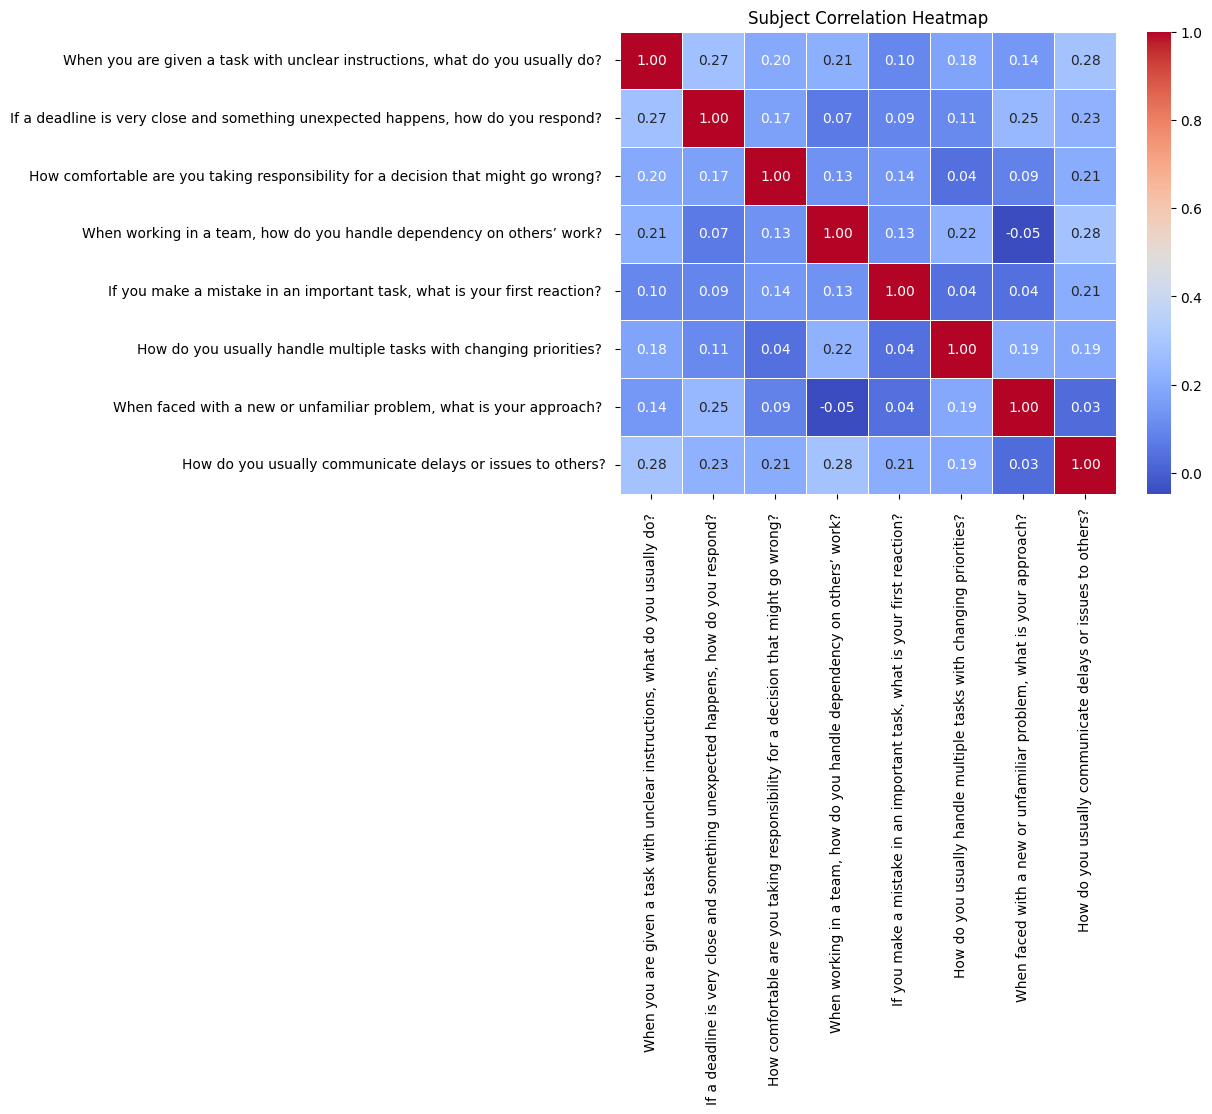

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = df.corr() #

# 3. Create the heatmap using Seaborn
plt.figure(figsize=(8, 6)) # Optional: Adjust the figure size
sns.heatmap(
    correlation_matrix,
    annot=True,       # Display correlation values in the cells
    cmap='coolwarm',  # Choose a color map (e.g., 'coolwarm', 'RdBu_r')
    fmt='.2f',        # Format the annotations to 2 decimal places
    linewidths=0.5    # Add lines between cells
)

# 4. Add title and display the plot
plt.title('Subject Correlation Heatmap')
plt.show()

In [ ]:
X = df.iloc[:,0:8]
X

,"When you are given a task with unclear instructions, what do you usually do?","If a deadline is very close and something unexpected happens, how do you respond?",How comfortable are you taking responsibility for a decision that might go wrong?,"When working in a team, how do you handle dependency on others’ work?","If you make a mistake in an important task, what is your first reaction?",How do you usually handle multiple tasks with changing priorities?,"When faced with a new or unfamiliar problem, what is your approach?",How do you usually communicate delays or issues to others?
0,3,2,2,5,3,5,5,4
1,4,4,5,5,5,4,2,5
2,3,4,2,5,3,4,3,3
3,1,3,4,5,5,1,2,3
4,5,5,2,5,5,5,4,5
...,...,...,...,...,...,...,...,...
211,2,3,2,3,4,1,4,2
212,2,2,3,2,2,1,3,3
213,4,2,3,1,5,4,4,3
214,4,5,4,5,4,5,4,5


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np

#  STEP 1: Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#  STEP 2: GMM
gmm = GaussianMixture(
    n_components=3,
    random_state=42,
    n_init=10   #  stability
)

gmm.fit(X_train)

#  STEP 3: ALWAYS use scaled data
train_prob = gmm.predict_proba(X_train)
test_prob = gmm.predict_proba(X_test)

#  STEP 4: labels
y_train = np.argmax(train_prob, axis=1)
y_test = np.argmax(test_prob, axis=1)

In [ ]:
cluster_means = gmm.means_.mean(axis=1)

sorted_idx = np.argsort(cluster_means)

mapping = {old: new for new, old in enumerate(sorted_idx)}

y_train = np.array([mapping[i] for i in y_train])
y_test = np.array([mapping[i] for i in y_test])

In [ ]:
import pandas as pd

print("Train clusters:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTest clusters:")
print(pd.Series(y_test).value_counts().sort_index())

Train clusters:
0    41
1    54
2    56
Name: count, dtype: int64

Test clusters:
0    19
1    19
2    27
Name: count, dtype: int64


In [ ]:
svm = SVC(C=0.007, kernel='linear', probability=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=15,
    max_depth=2,
    min_samples_split=15,
    min_samples_leaf=5,
    random_state=42
)

lr = LogisticRegression(C=0.005, max_iter=1000)

knn = KNeighborsClassifier(n_neighbors=50)

dt = DecisionTreeClassifier(max_depth=2, random_state=42)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [ ]:
models = {
    "SVM": svm,
    "Random Forest": rf,
    "Logistic Regression": lr,
    "KNN": knn,
    "Decision Tree": dt
}

print("\n===== K-FOLD CROSS VALIDATION (ALL METRICS) =====")
from sklearn.model_selection import cross_validate

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision_weighted',
            'recall': 'recall_weighted',
            'f1': 'f1_weighted'
        }
    )

    print(f"\n{name}:")
    print("Accuracy:", scores['test_accuracy'].mean())
    print("Precision:", scores['test_precision'].mean())
    print("Recall:", scores['test_recall'].mean())
    print("F1 Score:", scores['test_f1'].mean())
    print("-----------------------------------")


===== K-FOLD CROSS VALIDATION (ALL METRICS) =====

SVM:
Accuracy: 0.7623655913978495
Precision: 0.800274400330852
Recall: 0.7623655913978495
F1 Score: 0.727157937607213
-----------------------------------

Random Forest:
Accuracy: 0.7556989247311828
Precision: 0.768436097952227
Recall: 0.7556989247311828
F1 Score: 0.7521119964654327
-----------------------------------

Logistic Regression:
Accuracy: 0.7490322580645162
Precision: 0.7480220699252957
Recall: 0.7490322580645162
F1 Score: 0.7094051751368576
-----------------------------------

KNN:
Accuracy: 0.7161290322580645
Precision: 0.7357976978218913
Recall: 0.7161290322580645
F1 Score: 0.6806768719065118
-----------------------------------

Decision Tree:
Accuracy: 0.7021505376344086
Precision: 0.7361704675253062
Recall: 0.7021505376344086
F1 Score: 0.6974725195485407
-----------------------------------


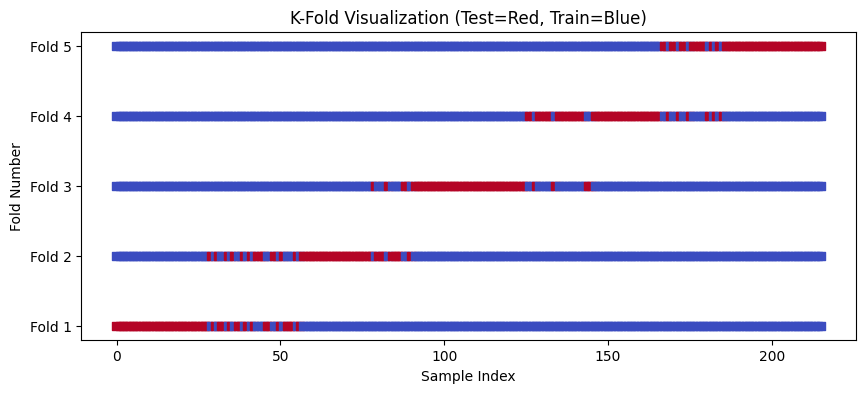

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Re-scale the full dataset X
X_scaled = scaler.transform(X)

# Get cluster probabilities for the full dataset using the fitted GMM
prob = gmm.predict_proba(X_scaled)

# Determine the final cluster labels for the full dataset
y = np.argmax(prob, axis=1)

# Use completely separate dummy variables
X_vis = np.zeros((len(y), 1))
y_vis = y.copy()

skf_vis = StratifiedKFold(n_splits=5)

plt.figure(figsize=(10, 4))

for i, (train_idx, test_idx) in enumerate(skf_vis.split(X_vis, y_vis)):
    fold_array = np.zeros(len(X_vis))
    fold_array[test_idx] = 1

    plt.scatter(range(len(fold_array)), [i+1]*len(fold_array),
                c=fold_array, cmap='coolwarm', marker='s')

plt.yticks(range(1, 6), [f"Fold {i}" for i in range(1, 6)])
plt.xlabel("Sample Index")
plt.ylabel("Fold Number")
plt.title("K-Fold Visualization (Test=Red, Train=Blue)")
plt.show()

In [ ]:
best_model = None
best_score = 0

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_weighted')
    mean_score = scores.mean()

    if mean_score > best_score:
        best_score = mean_score
        best_model = model

print("Best Model:", best_model)

Best Model: RandomForestClassifier(max_depth=2, min_samples_leaf=5, min_samples_split=15,
                       n_estimators=15, random_state=42)


/tmp/ipykernel_1728/3484436504.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample)


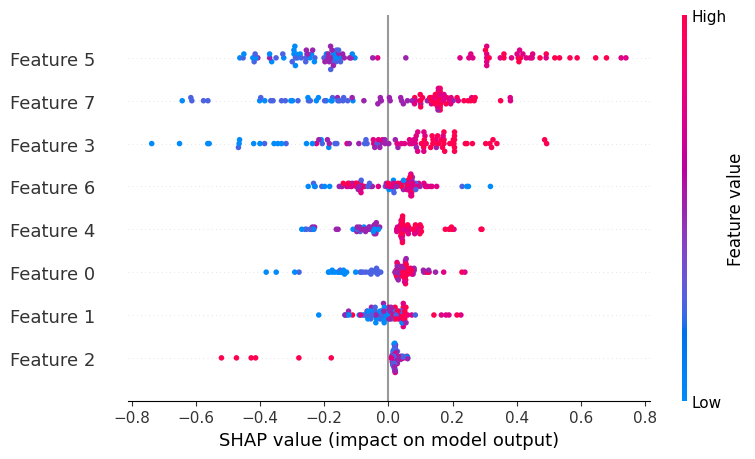

In [ ]:
# =========================
# SHAP ANALYSIS (SAFE VERSION)
# =========================
import shap
import numpy as np

# Create a small sample (important for speed & safety)
X_sample = X_train[:100]  # use only small subset

# Use model prediction function (safe for all models)
explainer = shap.Explainer(best_model.predict, X_sample)

# Calculate SHAP values
shap_values = explainer(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# FIXED classes
classes = np.unique(y_train)

# binarize TRUE labels (NOT test_prob)
y_test_bin = label_binarize(y_test, classes=classes)

# model prediction
y_score = best_model.predict_proba(X_test)

# AUC
auc_score = roc_auc_score(y_test_bin, y_score, average="micro")

print("AUC:", auc_score)

AUC: 0.890414201183432


In [ ]:
from sklearn.mixture import GaussianMixture


# probabilities
X_full_scaled = scaler.transform(X)
prob = gmm.predict_proba(X_full_scaled)

# final labels (no formula)
y = np.argmax(prob, axis=1)

# store in dataframe
df['Risk_cluster'] = y
cluster_means = gmm.means_.mean(axis=1)

sorted_idx = np.argsort(cluster_means)

mapping = {old: new for new, old in enumerate(sorted_idx)}
centers = gmm.means_.mean(axis=1)

df['Risk_cluster'] = df['Risk_cluster'].map(mapping)
print(df['Risk_cluster'].value_counts().sort_index())

Risk_cluster
0    60
1    73
2    83
Name: count, dtype: int64


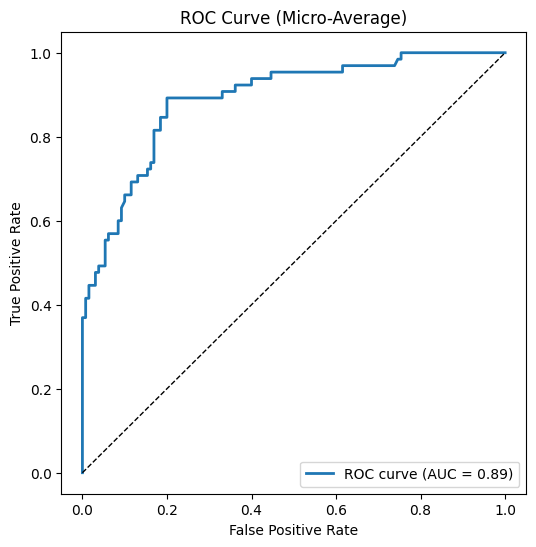

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(6,6))

# micro-average ROC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc, linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")

plt.show()

In [ ]:
new_data = np.array([[5,5,5,5,5,5,5,5]])

new_data = scaler.transform(new_data)

predicted_cluster = best_model.predict(new_data)[0]

labels = {0: "Low Risk Handling Capacity", 1: "Medium Risk Handling Capacity", 2: "High Risk Handling Capacity"}
print("Predicted Cluster:", predicted_cluster)
print("Predicted Level:", labels[predicted_cluster])

Predicted Cluster: 2
Predicted Level: High Risk Handling Capacity


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
def risk_recommendation(predicted_cluster):
    base = ""
    recommendation = ""

    # Define base message and specific recommendations
    if predicted_cluster == 0:
        base = "You are not fully prepared for real-world job situations yet."
        recommendation = "To improve, actively seek out learning opportunities, engage in mock interviews, and participate in projects to gain practical experience. Embrace challenges as opportunities for growth."
    elif predicted_cluster == 1:
        base = "You are moderately prepared but need improvement in some areas."
        recommendation = "Focus on identifying specific areas where you lack confidence, such as asking clarifying questions when instructions are unclear or practicing structured problem-solving. Consider mentorship or targeted skill development."
    else:
        base = "You are fully prepared for real-world job situations."
        recommendation = "Continue to hone your skills, take on leadership roles, and mentor others. Explore advanced topics and continuously adapt to new challenges to maintain your edge."

    # Utilize risk_label in the final output (risk_label is defined in cell 55-mEJAuFdwr)
    return f"Based on your responses, your estimated risk level is {labels[predicted_cluster]}. {base} {recommendation}"

print("Predicted Risk Level:", predicted_cluster)
print(risk_recommendation(predicted_cluster))

Predicted Risk Level: 2
Based on your responses, your estimated risk level is High Risk Handling Capacity. You are fully prepared for real-world job situations. Continue to hone your skills, take on leadership roles, and mentor others. Explore advanced topics and continuously adapt to new challenges to maintain your edge.


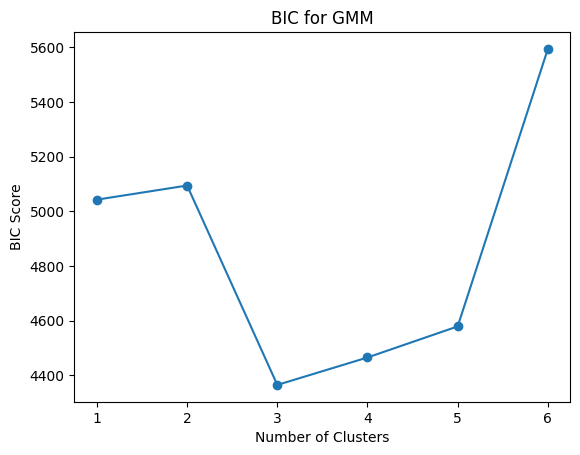

In [ ]:
from sklearn.mixture import GaussianMixture

bic_scores = []
k_values = range(1, 7)
X_scaled = scaler.transform(X)
for k in k_values:
    gmm_temp = GaussianMixture(n_components=k,n_init = 10, random_state=42)
    gmm_temp.fit(X_scaled)
    bic_scores.append(gmm_temp.bic(X_scaled))

# plot
import matplotlib.pyplot as plt

plt.plot(k_values, bic_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("BIC Score")
plt.title("BIC for GMM")
plt.show()

In [ ]:
from sklearn.decomposition import PCA

# PCA
probs = gmm.predict_proba(X_scaled)
confidence = probs.max(axis=1)

# sirf strong points lo
mask = confidence > 0.7

X_clean = X_scaled[mask]
pca = PCA(n_components=2)
pca.fit(X_scaled)

X_pca = pca.transform(X_clean)

# 🔥 GMM centers (means)
centroids = gmm.means_

# apply same mapping (low, medium, high)
centroids_corrected = np.zeros((centroids.shape[0], centroids.shape[1]))

for old_label, new_label in mapping.items():
    centroids_corrected[new_label] = centroids[old_label]

# transform centroids to PCA space
centroids_pca = pca.transform(centroids_corrected)

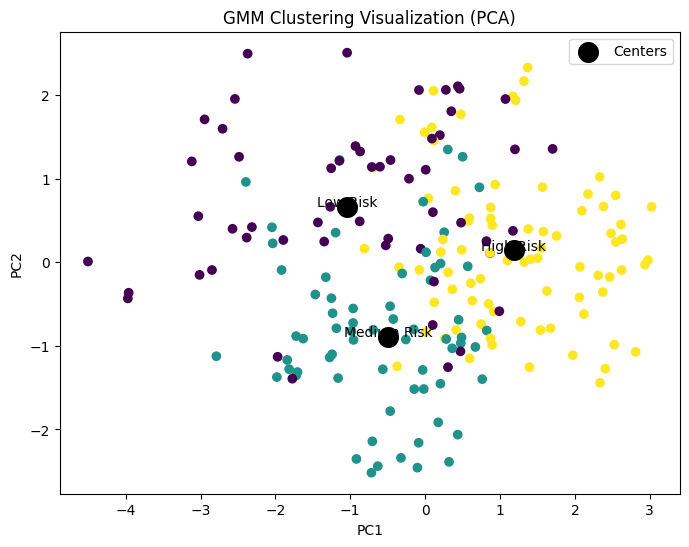

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Define labels_clean using gmm.predict on X_clean
labels_clean = gmm.predict(X_clean)
labels_clean = np.array([mapping[i] for i in labels_clean])

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_clean,
    cmap='viridis',
    vmin=0,
    vmax=2
)

# centroids
plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    c='black',
    s=200,
    label='Centers'
)

cluster_display_labels = ["Low Risk", "Medium Risk", "High Risk"]

for i in range(gmm.n_components): # Iterate for all clusters
    plt.text(
        centroids_pca[i,0],
        centroids_pca[i,1],
        cluster_display_labels[i],
        color='black',
        fontsize=10,
        ha='center'
    )

plt.title("GMM Clustering Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.show()

In [ ]:
joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(gmm, "gmm.pkl")

['gmm.pkl']